In [1]:
#import torch
#from pyarrow import float32

#print(torch.__version__)

In [2]:
import numpy as np
from sklearn import linear_model
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
np.random.seed(50)
X=np.linspace(-3,3,100).reshape(-1,1)
Y=np.cos(X)+np.random.randn(100,1)*0.2

In [4]:
X_tensor = torch.tensor(X,dtype=torch.float32)
y_tensor = torch.tensor(Y,dtype = torch.float32)

In [5]:
X_train,X_val,y_train,y_val = train_test_split(X_tensor,y_tensor,test_size = 0.3 , random_state = 42)


<function matplotlib.pyplot.show(close=None, block=None)>

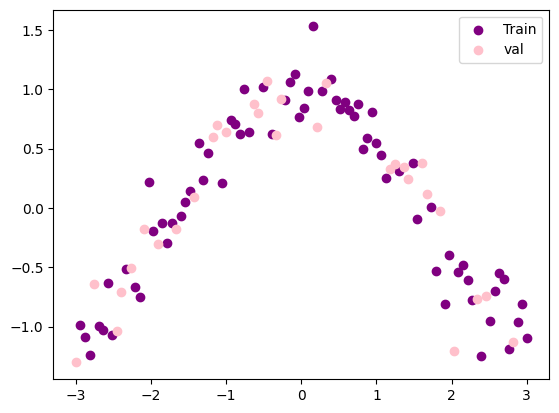

In [6]:
plt.scatter(X_train.numpy(),y_train.numpy(),label = "Train",color = "purple")
plt.scatter(X_val.numpy(),y_val.numpy(),label = "val",color = "pink")
plt.legend()
plt.show

## 数据准备好了，下面用两个神经网络来直观感受方差和偏差,分别是欠拟合和过拟合

In [7]:
class Flexible_NetWork(nn.Module):
    #self 在python的类里面指的就是自己，一个临时变量
    #hidden_size为隐藏神经元的数量，越多那么这个神经元就越大
    def __init__(self,hidden_size):
        super(Flexible_NetWork,self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1,hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size,1)
        )
    def forward(self,x):
            return self.net(x)

In [8]:
def train_and_diagnose(hidden_size,epoches = 2000,weight_decay = 0.0):
    #这里用hidden_size是因为我这里想要实现一个测试方差，偏差等等的不同情况，所以这样方便修改参数
    model = Flexible_NetWork(hidden_size)
    #定义损失函数，这里用的是均方误差损失函数
    criterion = nn.MSELoss()
    #criterion = nn.CrossEntropyLoss()此为交叉熵损失函数，专门为了分类问题设计的
    #定义Adam优化器，这个可以自动选择学习率保证速度
    optimizer = optim.Adam(model.parameters(),lr= 0.01,weight_decay = weight_decay)

    train_losses = []
    val_losses = []
    #虽然Module很强，但是针对一切的训练我们都要自己写训练的这个循环过程
    for epoch in range(epoches):
        model.train()
        optimizer.zero_grad()

        outputs = model(X_train)
        loss = criterion(outputs,y_train)

        loss.backward()
        optimizer.step()
    #eval就是告诉函数进入评估模式，不需要计算梯度等等的一切东西，只要计算损失就中
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs,y_val)
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
    return model , train_losses,val_losses

In [9]:
model_under, train_loss_under, val_loss_under = train_and_diagnose(hidden_size=2)

print(f"欠拟合网络 -> 最终 Train Loss: {train_loss_under[-1]:.4f} | Val Loss: {val_loss_under[-1]:.4f}")

欠拟合网络 -> 最终 Train Loss: 0.5748 | Val Loss: 0.5082


In [10]:
model_over, train_loss_over, val_loss_over = train_and_diagnose(hidden_size=500, weight_decay=0.0)

print(f"过拟合网络 -> 最终 Train Loss: {train_loss_over[-1]:.4f} | Val Loss: {val_loss_over[-1]:.4f}")

过拟合网络 -> 最终 Train Loss: 0.0335 | Val Loss: 0.0575


In [11]:
model_good, train_loss_good, val_loss_good = train_and_diagnose(hidden_size=500, weight_decay=0.01)

print(f"正则化网络 -> 最终 Train Loss: {train_loss_good[-1]:.4f} | Val Loss: {val_loss_good[-1]:.4f}")

正则化网络 -> 最终 Train Loss: 0.0413 | Val Loss: 0.0580


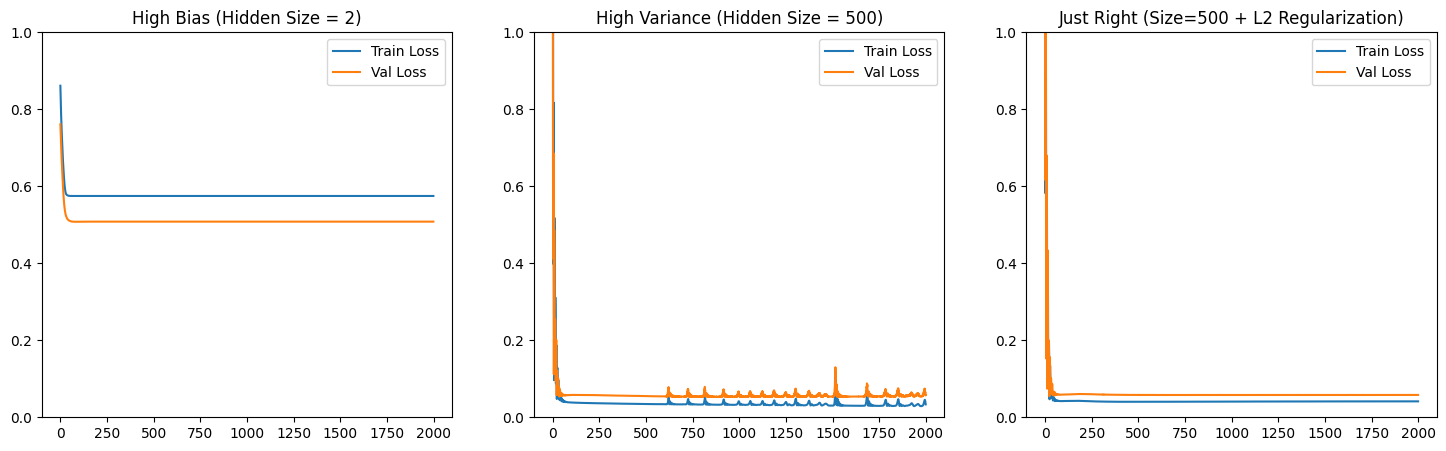

In [12]:
epochs_range = range(len(train_loss_under))

plt.figure(figsize=(18, 5))

# 1. 欠拟合曲线
plt.subplot(1, 3, 1)
plt.plot(epochs_range, train_loss_under, label='Train Loss')
plt.plot(epochs_range, val_loss_under, label='Val Loss')
plt.title("High Bias (Hidden Size = 2)")
plt.ylim(0, 1.0)
plt.legend()

# 2. 过拟合曲线
plt.subplot(1, 3, 2)
plt.plot(epochs_range, train_loss_over, label='Train Loss')
plt.plot(epochs_range, val_loss_over, label='Val Loss')
plt.title("High Variance (Hidden Size = 500)")
plt.ylim(0, 1.0)
plt.legend()

# 3. 刚刚好（正则化后）
plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_loss_good, label='Train Loss')
plt.plot(epochs_range, val_loss_good, label='Val Loss')
plt.title("Just Right (Size=500 + L2 Regularization)")
plt.ylim(0, 1.0)
plt.legend()

plt.show()